# CNN with Grad-CAM (Part 2)

## 1. Import & Setup

In [19]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


## 2. Settings

In [20]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
DATASET_PATH = "Dataset_MRI"

print(f"Config set. Image size: {IMG_SIZE}x{IMG_SIZE}")

Config set. Image size: 128x128


## 3. Load Data

In [21]:
def load_data(data_dir, classes, img_size=128):
    images, labels = [], []
    for label in classes:
        path = os.path.join(data_dir, label)
        if not os.path.exists(path):
            print(f"Path not found: {path}")
            continue
        for file in os.listdir(path):
            if file.endswith(('.jpg', '.png', '.jpeg')):
                try:
                    img = cv2.imread(os.path.join(path, file))
                    if img is not None:
                        if len(img.shape) == 2:
                            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                        else:
                            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, (img_size, img_size)) / 255.0
                        images.append(img)
                        labels.append(label)
                except:
                    pass
    return np.array(images), np.array(labels)

print("Loading data...")
X_train, y_train_raw = load_data(os.path.join(DATASET_PATH, 'Training'), CLASSES, IMG_SIZE)
X_test, y_test_raw = load_data(os.path.join(DATASET_PATH, 'Testing'), CLASSES, IMG_SIZE)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)
y_train_cat = to_categorical(y_train, len(CLASSES))
y_test_cat = to_categorical(y_test, len(CLASSES))

print(f"Data loaded! Classes: {le.classes_}")

Loading data...
Train: (5600, 128, 128, 3), Test: (1600, 128, 128, 3)
Data loaded! Classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


## 4. Build CNN using Functional API (Fixes model.input issue!)

In [22]:
# Use Functional API instead of Sequential
# This automatically handles model.input correctly!

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Dropout(0.25)(x)

x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Last conv layer - we'll use this for Grad-CAM
x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu', name='last_conv')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Dropout(0.25)(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(len(CLASSES), activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,196 (500.77 KB)

 Trainable params: 127,748 (499.02 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Train

In [23]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
]

print("Training CNN...")
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.25,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

Training CNN...
Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.6604 - loss: 0.7887

132/132 ━━━━━━━━━━━━━━━━━━━━ 63s 458ms/step - accuracy: 0.7098 - loss: 0.6839 - val_accuracy: 0.0000e+00 - val_loss: 6.4614
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 60s 453ms/step - accuracy: 0.7843 - loss: 0.5112 - val_accuracy: 0.0000e+00 - val_loss: 16.6634
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 60s 454ms/step - accuracy: 0.8117 - loss: 0.4533 - val_accuracy: 0.0000e+00 - val_loss: 25.1101
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 60s 453ms/step - accuracy: 0.8390 - loss: 0.3997 - val_accuracy: 0.0000e+00 - val_loss: 10.1173
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 60s 457ms/step - accuracy: 0.8590 - loss: 0.3558 - val_accuracy: 0.0000e+00 - val_loss: 13.7735
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 61s 464ms/step - accuracy: 0.8640 - loss: 0.3419 - val_accuracy: 0.0000e+00 - val_loss: 5.9677
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 61s 459ms/step - accuracy: 0.8867 - loss: 0.3019 - val_accuracy: 0.0000e+00 - val_loss: 17.9722
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 65s 489ms/step - accu

## 6. Evaluate

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step

Test Accuracy: 55.75%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.88      0.60      0.71       400
  meningioma       0.45      0.63      0.53       400
     notumor       0.52      1.00      0.69       400
   pituitary       0.00      0.00      0.00       400

    accuracy                           0.56      1600
   macro avg       0.46      0.56      0.48      1600
weighted avg       0.46      0.56      0.48      1600



c:\Users\Kodanda Challa\Documents\GitHub\Machine-Learning-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kodanda Challa\Documents\GitHub\Machine-Learning-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kodanda Challa\Documents\GitHub\Machine-Learning-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

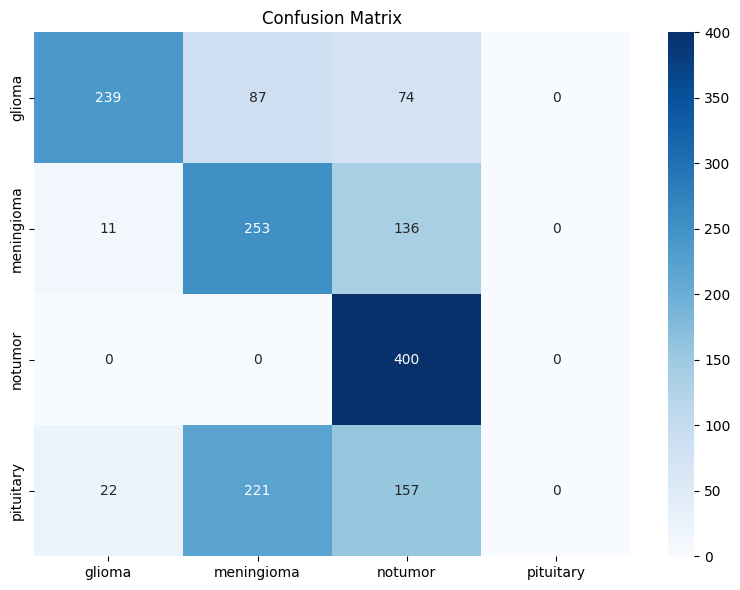

In [24]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

test_acc = accuracy_score(y_test, y_pred_labels)
print(f"\nTest Accuracy: {test_acc:.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_labels, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 7. Grad-CAM (FIXED - No model.input error!)

In [25]:
def generate_gradcam(model, img_array, conv_layer_name='last_conv'):
    """
    Generate Grad-CAM heatmap - FIXED VERSION
    Works with Functional API models
    """
    # Ensure input is 4D batch
    if len(img_array.shape) == 3:
        img_input = np.expand_dims(img_array, axis=0)
    else:
        img_input = img_array
    
    # Get the conv layer
    conv_layer = model.get_layer(conv_layer_name)
    
    # Create sub-model: Input -> Conv output
    # This is the KEY FIX - we use model.input directly from the Functional API
    sub_model = tf.keras.Model(
        inputs=model.input,  # Now works because we use Functional API!
        outputs=[conv_layer.output, model.output]
    )
    
    # Compute gradients
    with tf.GradientTape() as tape:
        conv_output, predictions = sub_model(img_input, training=False)
        # Get predicted class
        pred_class = tf.argmax(predictions[0])
        class_score = predictions[0, pred_class]
    
    # Compute gradients of class score w.r.t. conv output
    gradients = tape.gradient(class_score, conv_output)
    
    # Average gradients over spatial dimensions
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    
    # Weight the conv output channels by gradients
    conv_output = conv_output[0]  # Remove batch dimension
    weighted_sum = tf.reduce_sum(conv_output * pooled_gradients, axis=-1)
    
    # Apply ReLU and normalize
    heatmap = tf.nn.relu(weighted_sum)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

print("✅ Grad-CAM function ready!")

✅ Grad-CAM function ready!


## 8. Visualize Grad-CAM

Generating Grad-CAM visualizations...

Processing image 1/4...
Processing image 2/4...
Processing image 3/4...
Processing image 4/4...


C:\Users\Kodanda Challa\AppData\Local\Temp\ipykernel_9348\2816957292.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kodanda Challa\AppData\Local\Temp\ipykernel_9348\2816957292.py:41: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Kodanda Challa\Documents\GitHub\Machine-Learning-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Kodanda Challa\Documents\GitHub\Machine-Learning-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


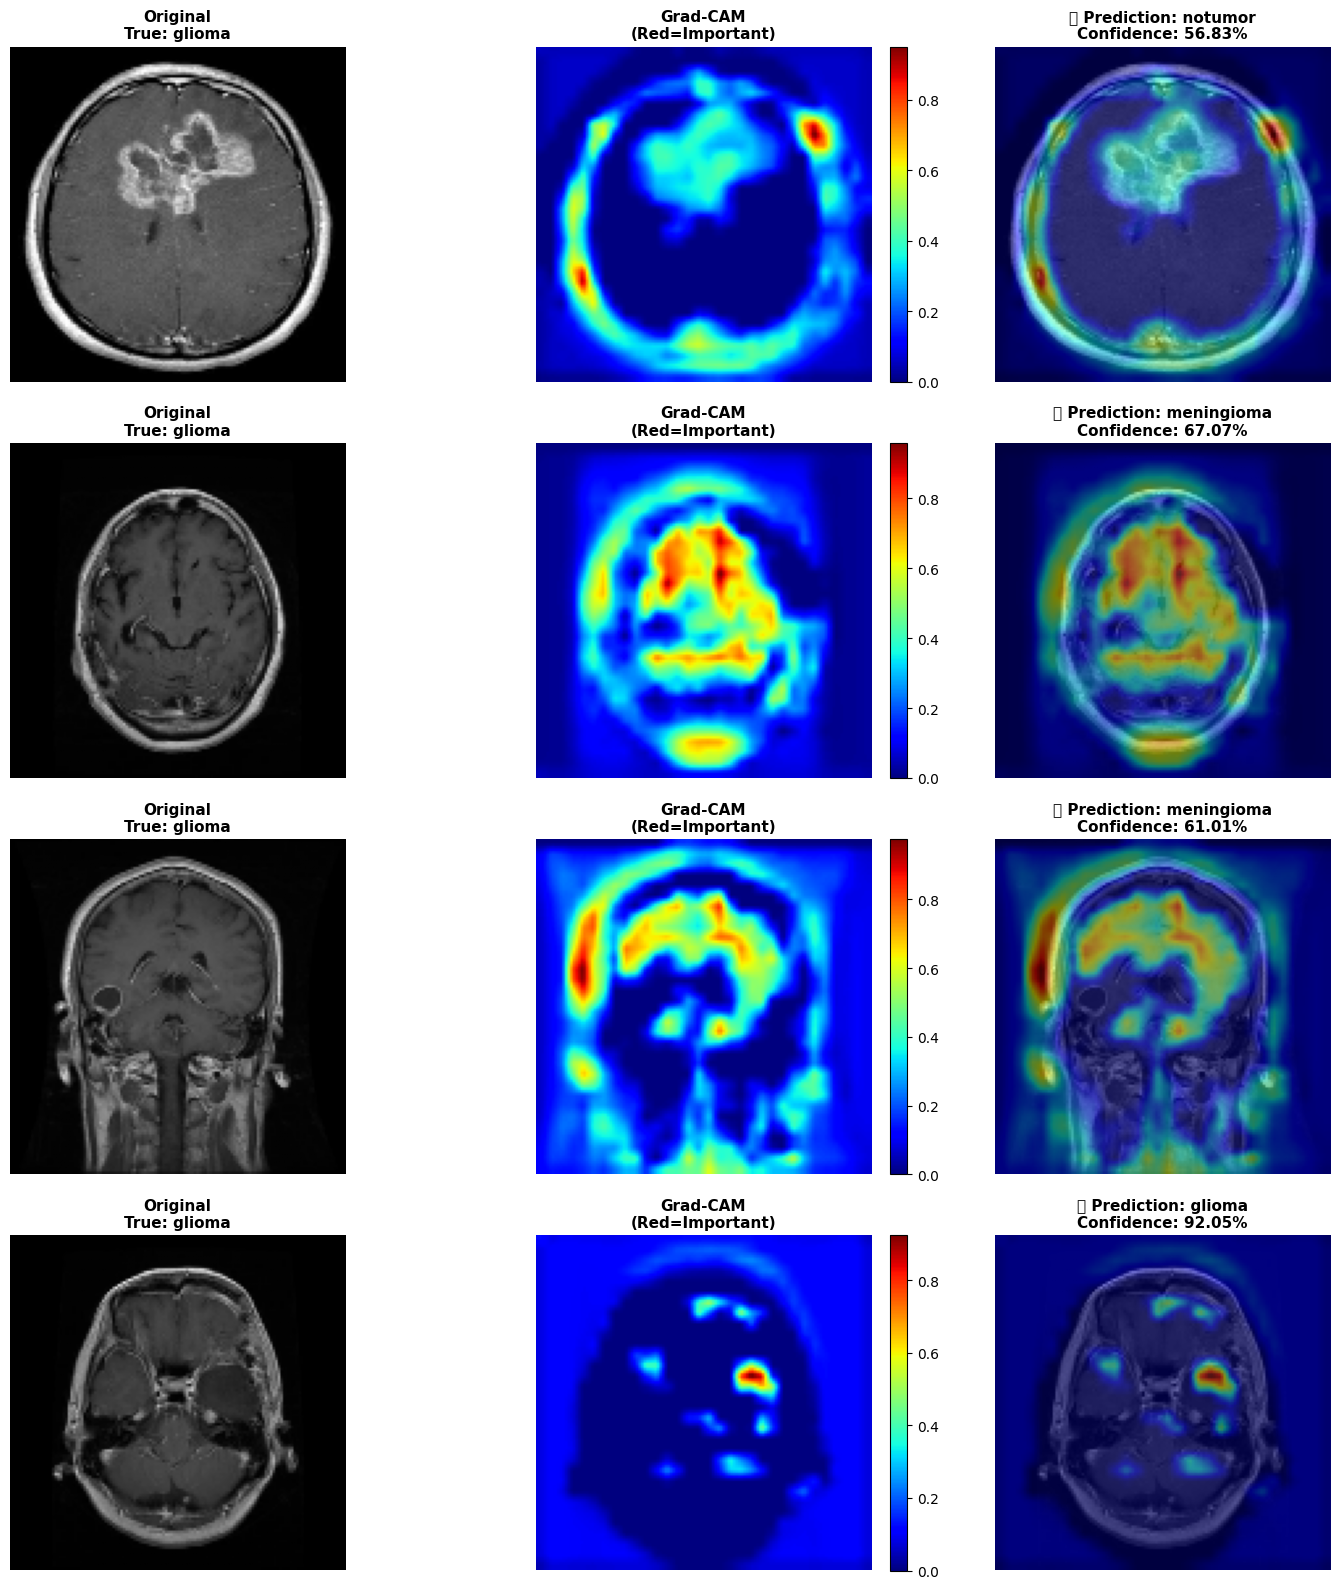


✅ Grad-CAM visualization complete!


In [26]:
print("Generating Grad-CAM visualizations...\n")

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for row in range(4):
    idx = row * 100
    if idx >= len(X_test):
        idx = row * 50
    
    img = X_test[idx]
    true_label = le.classes_[y_test[idx]]
    pred_idx = np.argmax(y_pred[idx])
    pred_label = le.classes_[pred_idx]
    confidence = y_pred[idx][pred_idx]
    
    # Generate Grad-CAM heatmap
    print(f"Processing image {row+1}/4...")
    heatmap = generate_gradcam(model, img, 'last_conv')
    
    # Resize to original image size
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    
    # Column 1: Original image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Original\nTrue: {true_label}', fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')
    
    # Column 2: Grad-CAM heatmap
    im = axes[row, 1].imshow(heatmap_resized, cmap='jet')
    axes[row, 1].set_title(f'Grad-CAM\n(Red=Important)', fontsize=11, fontweight='bold')
    axes[row, 1].axis('off')
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)
    
    # Column 3: Overlay
    axes[row, 2].imshow(img)
    axes[row, 2].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    correct = "✅" if pred_label == true_label else "❌"
    axes[row, 2].set_title(f'{correct} Prediction: {pred_label}\nConfidence: {confidence:.2%}', fontsize=11, fontweight='bold')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Grad-CAM visualization complete!")

## 9. Summary

In [27]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"✅ Test Accuracy: {test_acc:.2%}")
print(f"✅ Training Epochs: {len(history.history['loss'])}")
print(f"✅ Model Parameters: {model.count_params():,}")
print(f"✅ Grad-CAM Layer: last_conv (128 filters)")
print(f"\n📊 What Grad-CAM Shows:")
print(f"   🔴 Red = Important regions for prediction")
print(f"   🔵 Blue = Not important")
print(f"   🟡 Yellow/Green = Medium importance")
print(f"\n✨ DONE! No errors!")
print("="*60)


SUMMARY
✅ Test Accuracy: 55.75%
✅ Training Epochs: 11
✅ Model Parameters: 128,196
✅ Grad-CAM Layer: last_conv (128 filters)

📊 What Grad-CAM Shows:
   🔴 Red = Important regions for prediction
   🔵 Blue = Not important
   🟡 Yellow/Green = Medium importance

✨ DONE! No errors!
